Here is your simple summary:

* **Matrix Composition:** Combines multiple individual transformations into a single matrix.
$$\text{Scale} \times \text{Rotate} \times \text{Translate} = \text{Composite Matrix}$$

* **Matrix Decomposition:** Breaks down one complex matrix back into its pure, individual transformations.
$$\text{Composite Matrix} = \text{Scale} \times \text{Rotate} \times \text{Translate}$$


# Linear transformation 

In [17]:
import plotly.graph_objects as go
import numpy as np
from plotly.subplots import make_subplots

n=m=5
#set up  the lists  of  vertical line x and y-end coordinates

xv = []
yv = []
for k in range(-n, n+1):
    xv.extend([k, k, np.nan])
    yv.extend([-m, m, np.nan])

#set up  the lists  of  horizontal line x and y-end coordinates

xh=[]
yh=[]
for k in range(-m, m+1):
    xh.extend([-m, m, np.nan])
    yh.extend([k, k, np.nan])

x=np.array(xv+xh)
y=np.array(yv+yh)

# Linear transformation 
T = np.array([[3, -2], [2, 1]], dtype=float)
xy=np.stack((x,y))
xy_T=T.T@xy

fig=go.Figure(
    data=[
        go.Scatter(x=x, y=y, line_width=1), 
        go.Scatter(x=[0,0.01], y=[0,0],line_width=3), 
        go.Scatter(x=[0,0], y=[0,0.01],line_width=3) 
        
    ],
    layout=go.Layout(
        showlegend=False,
        xaxis=dict(range=[-n, n], autorange=False),
        yaxis=dict(range=[-m, m], autorange=False),
        width=500,
        height=500,
        updatemenus=[
                dict(
                    type="buttons",
                    buttons=[dict(label="Play",method="animate",args=[None])]
                )
        ]
    ),
    frames=[
        go.Frame(data=[
                go.Scatter(x=x, y=y, line_width=1), 
                go.Scatter(x=[0,0.01], y=[0,0],line_width=3), 
                go.Scatter(x=[0,0], y=[0,0.01],line_width=3) 
            ]
        ),
        go.Frame(data=[
                go.Scatter(x=x, y=y, line_width=1),

                go.Scatter(x=[0,1], y=[0,0], line_width=3), # i=[1,0]
                go.Scatter(x=[0,0], y=[0,1], line_width=3) # j=[0,1]
            ]
        ),
        go.Frame(data=[

                go.Scatter(x=xy_T[0], y=xy_T[1],line_width=1),

                go.Scatter(x=[0,T[0][0]], y=[0,T[0][1]], line_width=3), # i=[3,-2]
                go.Scatter(x=[0,T[1][0]], y=[0,T[1][1]], line_width=3), # j=[2,1]
            ]
        ),
    ]
    
)

fig.show()

# Matrix Compositon and Decmposition 

In [18]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Setup original grid coordinates
n = m = 5
xv, yv, xh, yh = [], [], [], []

for k in range(-n, n+1):
    xv.extend([k, k, np.nan])
    yv.extend([-m, m, np.nan])
for k in range(-m, m+1):
    xh.extend([-m, m, np.nan])
    yh.extend([k, k, np.nan])

# Combine into coordinate arrays
x_orig = np.array(xv + xh)
y_orig = np.array(yv + yh)

# Convert to 3D Homogeneous Coordinates [X, Y, 1]^T for complete 2D transformation control
# We mask out NaNs during transformation to avoid matrix errors, then restore them
valid_mask = ~np.isnan(x_orig)
grid_hom = np.ones((3, len(x_orig)))
grid_hom[0, valid_mask] = x_orig[valid_mask]
grid_hom[1, valid_mask] = y_orig[valid_mask]

# Define Basis Vectors (i-hat and j-hat) points
# Structuring: [Start, End, NaN]
basis_i = np.array([[0, 1, np.nan], [0, 0, np.nan], [1, 1, 1]])
basis_j = np.array([[0, 0, np.nan], [0, 1, np.nan], [1, 1, 1]])

# 2. Define the individual Transformation Matrices
tx, ty = 2, 1          # Translate
theta = np.radians(45) # Rotate
sx, sy = 1.5, 0.6      # Scale

T = np.array([[1, 0, tx], [0, 1, ty], [0, 0, 1]], dtype=float)
R = np.array([[np.cos(theta), -np.sin(theta), 0], [np.sin(theta), np.cos(theta), 0], [0, 0, 1]], dtype=float)
S = np.array([[sx, 0, 0], [0, sy, 0], [0, 0, 1]], dtype=float)

# 3. Compute the Step-by-Step Cumulative Transformations
grid_stage1 = grid_hom                      # Step 1: Base State
grid_stage2 = T @ grid_stage1                # Step 2: Translated
grid_stage3 = R @ grid_stage2                # Step 3: Translated + Rotated
grid_stage4 = S @ grid_stage3                # Step 4: Translated + Rotated + Scaled (Composite Matrix Result)

# Apply same modifications to basis vectors
bi1, bj1 = basis_i, basis_j
bi2, bj2 = T @ bi1, T @ bj1
bi3, bj3 = R @ bi2, R @ bj2
bi4, bj4 = S @ bi3, S @ bj3

# Restore NaNs back into transformed grids for correct line splitting in Plotly
for grid in [grid_stage1, grid_stage2, grid_stage3, grid_stage4]:
    grid[0, ~valid_mask] = np.nan
    grid[1, ~valid_mask] = np.nan

# 4. Initialize Subplots Container
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "1. Base Grid (Identity)", 
        "2. Applied Translation (T)", 
        "3. Applied Rotation (R * T)", 
        "4. Final Composite State (S * R * T)"
    )
)

# Helper function to inject standard formatting layers cleanly into plots
def add_transformation_plot(fig, row, col, grid, bi, bj):
    # Plot background grid lines
    fig.add_trace(go.Scatter(x=grid[0], y=grid[1], mode='lines', line=dict(color='lightgray', width=1)), row=row, col=col)
    # Plot i-hat vector trace
    fig.add_trace(go.Scatter(x=bi[0], y=bi[1], mode='lines+markers', line=dict(color='crimson', width=3), marker=dict(size=6)), row=row, col=col)
    # Plot j-hat vector trace
    fig.add_trace(go.Scatter(x=bj[0], y=bj[1], mode='lines+markers', line=dict(color='royalblue', width=3), marker=dict(size=6)), row=row, col=col)

# Add data maps sequentially into designated quadrants
add_transformation_plot(fig, 1, 1, grid_stage1, bi1, bj1)
add_transformation_plot(fig, 1, 2, grid_stage2, bi2, bj2)
add_transformation_plot(fig, 2, 1, grid_stage3, bi3, bj3)
add_transformation_plot(fig, 2, 2, grid_stage4, bi4, bj4)

# 5. Global Layout Controls
fig.update_layout(
    width=800,
    height=800,
    showlegend=False,
    template="plotly_white",
    title_text="Matrix Composition Breakdown across 4 Independent States",
    title_x=0.5
)

# Constrain ranges and secure aspect ratios across all 4 subplot domains
axis_config = dict(range=[-8, 8], autorange=False, scaleanchor="y", scaleratio=1, zeroline=True, zerolinecolor='gray')
fig.update_xaxes(axis_config)
fig.update_yaxes(range=[-8, 8], autorange=False, zeroline=True, zerolinecolor='gray')

fig.show()


<>:108: SyntaxWarning:

invalid escape sequence '\S'

<>:108: SyntaxWarning:

invalid escape sequence '\S'

C:\Users\sumit\AppData\Local\Temp\ipykernel_17416\1318716922.py:108: SyntaxWarning:

invalid escape sequence '\S'



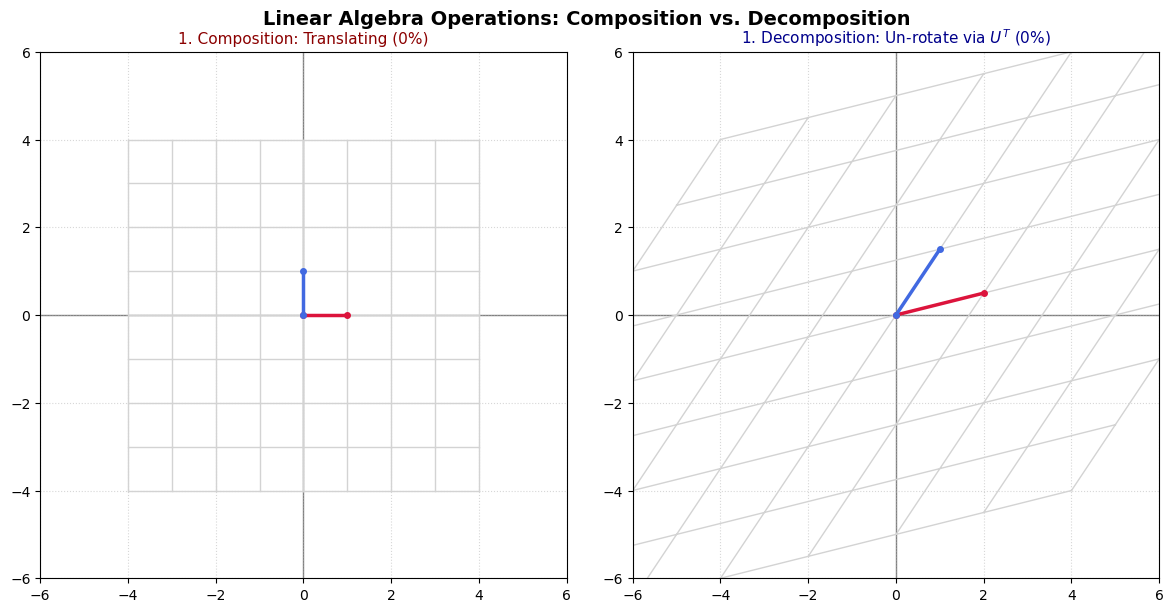

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# =============================================================================
# 1. GENERATE GRID DATA (Homogeneous Coordinates)
# =============================================================================
n = m = 4
xv, yv = [], []
for k in range(-n, n+1):
    xv.extend([k, k, np.nan])
    yv.extend([-m, m, np.nan])
for k in range(-m, m+1):
    xv.extend([-m, m, np.nan])
    yv.extend([k, k, np.nan])

x_orig = np.array(xv)
y_orig = np.array(yv)
valid = ~np.isnan(x_orig)

# 3 x N Homogeneous Matrix
grid_hom = np.ones((3, len(x_orig)))
grid_hom[0, valid] = x_orig[valid]
grid_hom[1, valid] = y_orig[valid]

# Basis Vectors: [Start, End, NaN]
bi_hom = np.array([[0, 1, np.nan], [0, 0, np.nan], [1, 1, np.nan]])
bj_hom = np.array([[0, 0, np.nan], [0, 1, np.nan], [1, 1, np.nan]])

# =============================================================================
# 2. DEFINE TRANSFORMS (Composition & Decomposition Matrices)
# =============================================================================
# Composition parameters
tx, ty = 1.5, 0.5
theta = np.radians(35)
sx, sy = 1.6, 0.7

T = np.array([[1, 0, tx], [0, 1, ty], [0, 0, 1]])
R = np.array([[np.cos(theta), -np.sin(theta), 0], [np.sin(theta), np.cos(theta), 0], [0, 0, 1]])
S = np.array([[sx, 0, 0], [0, sy, 0], [0, 0, 1]])

# Target composite transformation matrix
M_composite = S @ R @ T

# For Decomposition, we will invert a standard 2x2 matrix step-by-step using SVD
# Matrix to decompose: A = U * Sigma * V^T -> We animate backwards to return to base space!
A_2d = np.array([[2.0, 1.0], [0.5, 1.5]])
U_2d, Sigma_diag, Vt_2d = np.linalg.svd(A_2d)

# Upgrade SVD elements to 3x3 Homogeneous matrices
U = np.eye(3); U[:2, :2] = U_2d
Sigma_inv = np.eye(3); Sigma_inv[0,0] = 1/Sigma_diag[0]; Sigma_inv[1,1] = 1/Sigma_diag[1]
V = np.eye(3); V[:2, :2] = Vt_2d.T  # (V^T)^T = V

# Initial heavily warped state for the decomposition tracking plot
grid_decom_start = U @ np.diag([Sigma_diag[0], Sigma_diag[1], 1]) @ V.T @ grid_hom
bi_decom_start = U @ np.diag([Sigma_diag[0], Sigma_diag[1], 1]) @ V.T @ bi_hom
bj_decom_start = U @ np.diag([Sigma_diag[0], Sigma_diag[1], 1]) @ V.T @ bj_hom

# =============================================================================
# 3. INTERPOLATION FUNCTIONS FOR SMOOTH TRANSITIONS
# =============================================================================
def lerp_matrix(target_matrix, t):
    """Linearly interpolates from Identity to a Target matrix."""
    return np.eye(3) + t * (target_matrix - np.eye(3))

# Timeline parameters
frames_per_phase = 25
total_frames = frames_per_phase * 3

# Pre-calculate positions for speed
comp_history = []
decom_history = []
comp_titles = []
decom_titles = []

for frame in range(total_frames):
    # Determine what phase we are in (0, 1, or 2)
    phase = frame // frames_per_phase
    t = (frame % frames_per_phase) / (frames_per_phase - 1)
    
    # --- COMPOSITION STAGE calculation ---
    if phase == 0:  # Translation phase
        M_curr = lerp_matrix(T, t)
        title_c = f"1. Composition: Translating ({int(t*100)}%)"
    elif phase == 1: # Rotation phase
        M_curr = lerp_matrix(R, t) @ T
        title_c = f"2. Composition: Rotating ({int(t*100)}%)"
    else:           # Scaling phase
        M_curr = lerp_matrix(S, t) @ R @ T
        title_c = f"3. Composition: Scaling ({int(t*100)}%)"
        
    g_c = M_curr @ grid_hom
    g_c[0, ~valid] = np.nan; g_c[1, ~valid] = np.nan
    comp_history.append((g_c, M_curr @ bi_hom, M_curr @ bj_hom))
    comp_titles.append(title_c)
    
    # --- DECOMPOSITION STAGE calculation (Undoing operations via SVD components) ---
    if phase == 0:  # Undo Left Rotation (Apply U^T)
        M_dec = lerp_matrix(U.T, t)
        g_d = M_dec @ grid_decom_start
        bi_d, bj_d = M_dec @ bi_decom_start, M_dec @ bj_decom_start
        title_d = f"1. Decomposition: Un-rotate via $U^T$ ({int(t*100)}%)"
    elif phase == 1: # Undo Scaling (Apply Sigma^-1)
        M_dec = lerp_matrix(Sigma_inv, t) @ U.T
        g_d = M_dec @ grid_decom_start
        bi_d, bj_d = M_dec @ bi_decom_start, M_dec @ bj_decom_start
        title_d = f"2. Decomposition: Un-scale via $\Sigma^{{-1}}$ ({int(t*100)}%)"
    else:           # Undo Right Rotation (Apply V)
        M_dec = lerp_matrix(V, t) @ Sigma_inv @ U.T
        g_d = M_dec @ grid_decom_start
        bi_d, bj_d = M_dec @ bi_decom_start, M_dec @ bj_decom_start
        title_d = f"3. Decomposition: Un-rotate via $V$ ({int(t*100)}%)"
        
    g_d[0, ~valid] = np.nan; g_d[1, ~valid] = np.nan
    decom_history.append((g_d, bi_d, bj_d))
    decom_titles.append(title_d)

# =============================================================================
# 4. INITIALIZE MATPLOTLIB CANVAS FOR PLOTTING
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Linear Algebra Operations: Composition vs. Decomposition", fontsize=14, fontweight='bold')

# Setup Left Subplot (Composition)
grid_line_c, = ax1.plot([], [], color='lightgray', linewidth=1)
i_vector_c, = ax1.plot([], [], color='crimson', linewidth=2.5, marker='o', markersize=4)
j_vector_c, = ax1.plot([], [], color='royalblue', linewidth=2.5, marker='o', markersize=4)
ax1.set_xlim(-6, 6); ax1.set_ylim(-6, 6)
ax1.set_aspect('equal')
ax1.axhline(0, color='gray', linewidth=1, zorder=0)
ax1.axvline(0, color='gray', linewidth=1, zorder=0)
ax1.grid(True, linestyle=':', alpha=0.5)

# Setup Right Subplot (Decomposition)
grid_line_d, = ax2.plot([], [], color='lightgray', linewidth=1)
i_vector_d, = ax2.plot([], [], color='crimson', linewidth=2.5, marker='o', markersize=4)
j_vector_d, = ax2.plot([], [], color='royalblue', linewidth=2.5, marker='o', markersize=4)
ax2.set_xlim(-6, 6); ax2.set_ylim(-6, 6)
ax2.set_aspect('equal')
ax2.axhline(0, color='gray', linewidth=1, zorder=0)
ax2.axvline(0, color='gray', linewidth=1, zorder=0)
ax2.grid(True, linestyle=':', alpha=0.5)

# =============================================================================
# 5. ANIMATION UPDATE CONTROLLER
# =============================================================================
def update(frame):
    # Update Composition Plot (Left)
    gc, bic, bjc = comp_history[frame]
    grid_line_c.set_data(gc[0], gc[1])
    i_vector_c.set_data(bic[0], bic[1])
    j_vector_c.set_data(bjc[0], bjc[1])
    ax1.set_title(comp_titles[frame], color='darkred', fontsize=11)
    
    # Update Decomposition Plot (Right)
    gd, bid, bjd = decom_history[frame]
    grid_line_d.set_data(gd[0], gd[1])
    i_vector_d.set_data(bid[0], bid[1])
    j_vector_d.set_data(bjd[0], bjd[1])
    ax2.set_title(decom_titles[frame], color='darkblue', fontsize=11)
    
    return grid_line_c, i_vector_c, j_vector_c, grid_line_d, i_vector_d, j_vector_d

# Execute the smooth loop animation
ani = animation.FuncAnimation(
    fig, update, frames=total_frames, interval=60, blit=True, repeat=True
)

plt.tight_layout()
plt.show()


# Kernal PCA

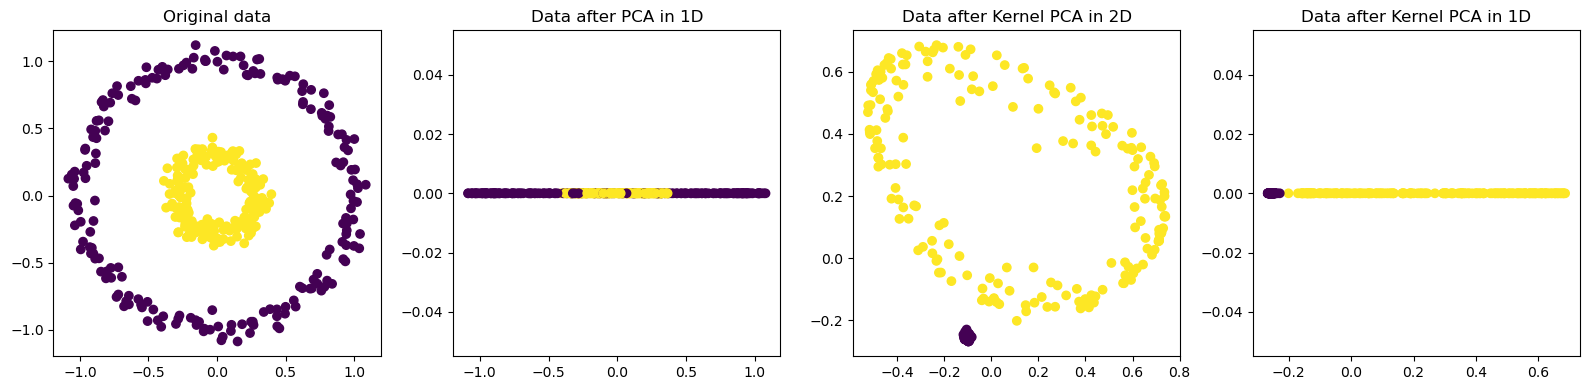

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_circles

# Generate the dataset
X, y = make_circles(n_samples=400, factor=.3, noise=.05)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X)

# Apply Kernel PCA
kpca = KernelPCA(kernel="rbf", gamma=10)
X_kpca = kpca.fit_transform(X)

# Original data plot
plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Original data')

# Transformed data with PCA in 1D
plt.subplot(1, 4, 2)
plt.scatter(X_pca[:, 0], np.zeros((400,)), c=y)
plt.title('Data after PCA in 1D')

# Transformed data with Kernel PCA in 2D
plt.subplot(1, 4, 3)
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y)
plt.title('Data after Kernel PCA in 2D')

# Transformed data with Kernel PCA in 1D
plt.subplot(1, 4, 4)
plt.scatter(X_kpca[:, 1], np.zeros((400,)), c=y)
plt.title('Data after Kernel PCA in 1D')

plt.tight_layout()
plt.show()


tho Kernal pca bhut ki stochastic hota ha .         
yadi hum kernel pca ka sath ek classification attach kar deta ho aor accuracy nikalta ho . 

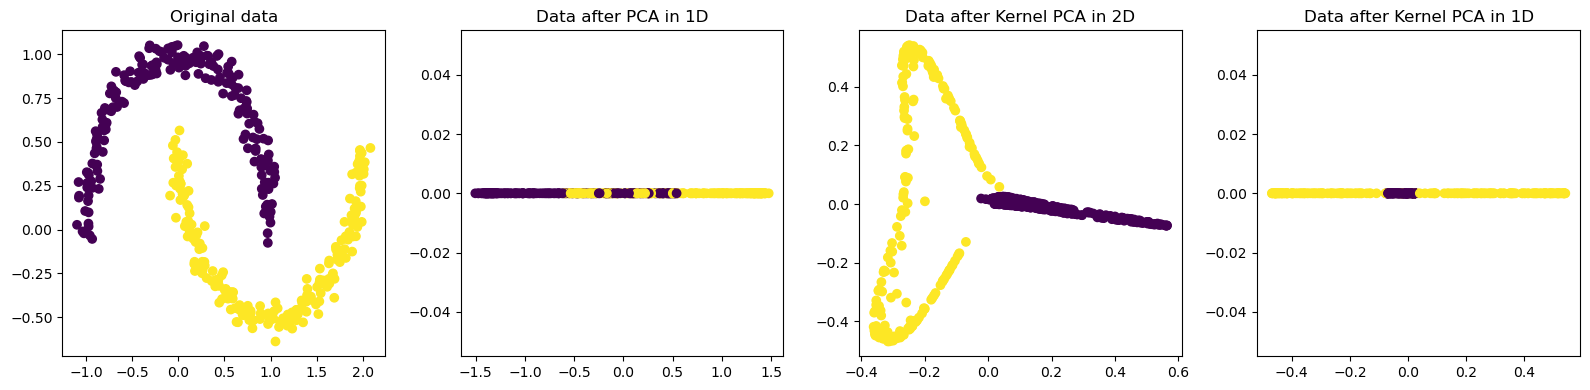

In [21]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_moons

# Generate the dataset
X, y = make_moons(n_samples=400, noise=.05)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X)

# Apply Kernel PCA
kpca = KernelPCA(kernel="rbf", gamma=15)
X_kpca = kpca.fit_transform(X)

# Original data plot
plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Original data')

# Transformed data with PCA in 1D
plt.subplot(1, 4, 2)
plt.scatter(X_pca[:, 0], np.zeros((400,)), c=y)
plt.title('Data after PCA in 1D')

# Transformed data with Kernel PCA in 2D
plt.subplot(1, 4, 3)
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y)
plt.title('Data after Kernel PCA in 2D')

# Transformed data with Kernel PCA in 1D
plt.subplot(1, 4, 4)
plt.scatter(X_kpca[:, 1], np.zeros((400,)), c=y)
plt.title('Data after Kernel PCA in 1D')

plt.tight_layout()
plt.show()


In [22]:
import plotly.graph_objs as go
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA
import numpy as np

# Create the half moon data
X, y = make_moons(n_samples=500, noise=0.02)

# Standardize the data
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Apply the RBF kernel PCA 
kpca = KernelPCA(n_components=3, kernel='rbf', gamma=15)
X_kpca = kpca.fit_transform(X_std)

# Create a trace for the original data
trace1 = go.Scatter(x=X_std[y==0, 0], y=X_std[y==0, 1], 
                    mode='markers', name='Class 0',
                    marker=dict(color='red', size=5, opacity=0.5))
trace2 = go.Scatter(x=X_std[y==1, 0], y=X_std[y==1, 1], 
                    mode='markers', name='Class 1',
                    marker=dict(color='blue', size=5, opacity=0.5))

# Create a trace for the transformed data
trace3 = go.Scatter3d(x=X_kpca[y==0, 0], y=X_kpca[y==0, 1], z=X_kpca[y==0, 2], 
                      mode='markers', name='Class 0',
                      marker=dict(color='red', size=5, opacity=0.5))
trace4 = go.Scatter3d(x=X_kpca[y==1, 0], y=X_kpca[y==1, 1], z=X_kpca[y==1, 2], 
                      mode='markers', name='Class 1',
                      marker=dict(color='blue', size=5, opacity=0.5))

# Create the layouts
layout1 = go.Layout(title='Original data in 2D', autosize=True, 
                    xaxis=dict(title='Feature 1'),
                    yaxis=dict(title='Feature 2'))
layout2 = go.Layout(title='Data after RBF Kernel PCA in 3D', autosize=True, 
                    scene=dict(xaxis=dict(title='PC 1'),
                               yaxis=dict(title='PC 2'),
                               zaxis=dict(title='PC 3')))

# Create the figures and plot
fig1 = go.Figure(data=[trace1, trace2], layout=layout1)
fig2 = go.Figure(data=[trace3, trace4], layout=layout2)

fig1.show()
fig2.show()


# kernel PCA step by step 

## make data

Text(0.5, 1.0, 'Original data')

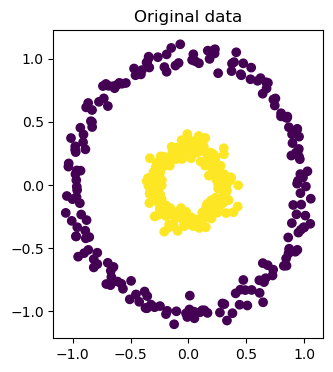

In [23]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_circles
import numpy as np

# Generate the dataset
X, y = make_circles(n_samples=400, factor=.3, noise=.05)

# Original data plot
plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Original data')

## mean centering 

In [24]:
X_centered = X - np.mean(X, axis=0)
# Mean centered around the origin 

Text(0.5, 1.0, 'Original data')

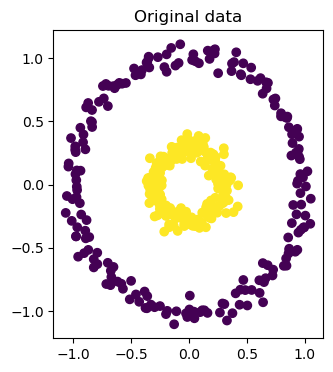

In [25]:
plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.scatter(X_centered[:, 0], X_centered[:, 1], c=y)
plt.title('Original data')

## Apply kernal Transformation 

$y = e^{-x^2}$



$e^{-\gamma . \text{distance}}$             
$\text{distance} =(x_1 - x_2)^2 $

In [26]:
def rbf_kernel(x1, x2, gamma=0.1):
    distance = np.linalg.norm(x1 - x2) ** 2
    return np.exp(-gamma * distance)

# Create the kernel matrix
n_samples = X.shape[0]
K = np.zeros((n_samples, n_samples))
for i in range(n_samples):
    for j in range(n_samples):
        K[i, j] = rbf_kernel(X_centered[i], X_centered[j])


In [27]:
X

array([[ 9.67666311e-01, -6.46531263e-02],
       [-4.00453910e-02,  3.22446509e-01],
       [ 2.55700887e-01,  8.79102924e-03],
       [-4.57365479e-01,  8.68657275e-01],
       [ 6.66849508e-01, -7.38145224e-01],
       [ 1.00025956e+00, -3.36329289e-01],
       [ 2.05634861e-01,  1.27073868e-01],
       [-8.83727544e-01,  6.14308669e-01],
       [-9.60595598e-01, -3.34614131e-01],
       [ 2.20962512e-02, -3.15018078e-01],
       [-2.40659041e-01,  2.26369192e-01],
       [-3.58838898e-01, -9.76316670e-01],
       [-3.02918423e-02,  2.82009126e-01],
       [ 1.01051417e+00, -2.42747393e-01],
       [-3.61690980e-02, -3.12120439e-01],
       [ 7.51561392e-01,  6.84736677e-01],
       [ 1.06253833e-01,  1.85374722e-01],
       [-7.12877154e-01,  7.99772772e-01],
       [-6.70832319e-01, -6.79554416e-01],
       [ 1.50069130e-03,  2.71931163e-01],
       [ 8.93615379e-01, -3.01945937e-01],
       [-9.30273989e-02, -3.63797286e-01],
       [-3.78607510e-01, -8.43722161e-01],
       [ 1.

## similaity matrix
calcuate distance score 

In [28]:
import pandas as pd

In [29]:
pd.DataFrame(K)

,0,1,2,3,4,5,6,7,8,9,...,390,391,392,393,394,395,396,397,398,399
0,1.000000,0.890001,0.950061,0.748130,0.947045,0.992541,0.940122,0.677826,0.684472,0.908756,...,0.909952,0.936383,0.678728,0.825817,0.769260,0.853881,0.914182,0.796789,0.883872,0.854539
1,0.890001,1.000000,0.981587,0.953849,0.850054,0.859313,0.990195,0.923395,0.879929,0.959808,...,0.998262,0.992767,0.916111,0.956812,0.871289,0.839166,0.998079,0.845004,0.968738,0.865902
2,0.950061,0.981587,1.000000,0.882688,0.929884,0.934870,0.998352,0.846627,0.852374,0.984184,...,0.985709,0.994450,0.854261,0.906626,0.890981,0.902998,0.988446,0.888009,0.979419,0.919173
3,0.748130,0.953849,0.882688,1.000000,0.680745,0.699306,0.905787,0.975653,0.843572,0.849509,...,0.944788,0.918693,0.938235,0.972401,0.767042,0.684195,0.939933,0.712847,0.876134,0.721411
4,0.947045,0.850054,0.929884,0.680745,1.000000,0.973106,0.908344,0.654855,0.754922,0.942260,...,0.859237,0.890288,0.691538,0.717630,0.873606,0.964241,0.867245,0.915646,0.914847,0.956210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.853881,0.839166,0.902998,0.684195,0.964241,0.886401,0.881617,0.698591,0.852248,0.954286,...,0.835177,0.858023,0.758586,0.677731,0.957705,1.000000,0.843768,0.986656,0.938248,0.997511
396,0.914182,0.998079,0.988446,0.939933,0.867245,0.884001,0.995468,0.899784,0.857455,0.961001,...,0.999843,0.998106,0.891178,0.956190,0.860852,0.843768,1.000000,0.841047,0.965684,0.867844
397,0.796789,0.845004,0.888009,0.712847,0.915646,0.823682,0.870840,0.749590,0.913838,0.952538,...,0.833251,0.847479,0.817422,0.680442,0.989832,0.986656,0.841047,1.000000,0.947525,0.992705
398,0.883872,0.968738,0.979419,0.876134,0.914847,0.879066,0.975975,0.879255,0.932455,0.997019,...,0.961889,0.965935,0.908889,0.860022,0.959880,0.938248,0.965684,0.947525,1.000000,0.957609


In [30]:
K.shape

(400, 400)

## apply eigen decompostion 

In [31]:
from scipy.linalg import eigh
eigenvalues, eigenvectors = eigh(K)

In [32]:
pd.DataFrame(eigenvectors)

,0,1,2,3,4,5,6,7,8,9,...,390,391,392,393,394,395,396,397,398,399
0,-0.037576,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.013307,-0.000765,-0.090530,-0.007385,-0.067278,0.076235,0.018082,-0.082756,-0.039999,-0.048158
1,0.691803,0.000336,0.000448,-0.000229,-0.000244,-0.000033,0.000074,-0.000237,-0.000072,0.000019,...,-0.004642,-0.095175,0.000545,-0.002158,0.047415,0.001179,0.004773,-0.008042,0.032111,-0.052080
2,-0.026227,-0.002298,-0.005510,0.005590,-0.011141,0.004765,-0.002276,-0.012236,-0.015099,-0.001036,...,-0.078006,0.011390,-0.003034,0.001240,0.046044,0.014726,0.016284,-0.024302,-0.009009,-0.052289
3,0.019635,0.037827,-0.025750,-0.061653,-0.047407,0.022477,-0.007051,0.032462,-0.049014,-0.064101,...,-0.000397,0.000884,-0.088627,-0.002349,-0.016312,-0.014104,-0.100379,0.009859,0.092077,-0.047998
4,-0.015749,-0.004096,0.024173,-0.001758,-0.010633,0.013304,0.023383,0.009179,-0.013191,-0.009026,...,0.002652,-0.011573,0.073683,-0.058582,-0.029454,0.026743,-0.098247,-0.031891,-0.087815,-0.047910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.052094,0.088673,0.022067,0.002085,-0.050943,0.030234,-0.036995,-0.066371,-0.014016,0.099752,...,-0.002375,-0.015097,0.037721,0.086521,-0.016205,-0.081820,-0.071818,0.025342,-0.090422,-0.047836
396,-0.049117,0.099988,0.024655,-0.070099,-0.000144,0.008800,0.095701,-0.009539,0.080389,0.045540,...,-0.044380,-0.084806,0.003347,-0.000711,0.045566,-0.002019,0.013435,-0.020839,0.025736,-0.052083
397,0.051305,-0.001058,-0.056358,-0.003805,-0.003911,-0.025385,0.011167,0.001234,-0.032595,-0.008058,...,-0.002457,-0.013130,-0.064763,0.071599,-0.028459,-0.105032,-0.007550,0.056379,-0.074775,-0.047901
398,0.010574,-0.062288,-0.027802,0.052796,0.041141,-0.021198,-0.007854,-0.101456,0.046866,-0.034540,...,0.052449,0.062864,-0.001376,-0.002418,0.047134,0.001819,0.016434,0.022262,-0.017193,-0.052231


In [33]:
eigenvectors.shape

(400, 400)

In [34]:
# Reverse the arrays as eigh returns them in ascending order
eigenvalues = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]

In [35]:
eigenvalues.shape

(400,)

In [37]:
pd.DataFrame(eigenvectors)

,0,1,2,3,4,5,6,7,8,9,...,390,391,392,393,394,395,396,397,398,399
0,-0.048158,-0.039999,-0.082756,0.018082,0.076235,-0.067278,-0.007385,-0.090530,-0.000765,0.013307,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.037576
1,-0.052080,0.032111,-0.008042,0.004773,0.001179,0.047415,-0.002158,0.000545,-0.095175,-0.004642,...,0.000019,-0.000072,-0.000237,0.000074,-0.000033,-0.000244,-0.000229,0.000448,0.000336,0.691803
2,-0.052289,-0.009009,-0.024302,0.016284,0.014726,0.046044,0.001240,-0.003034,0.011390,-0.078006,...,-0.001036,-0.015099,-0.012236,-0.002276,0.004765,-0.011141,0.005590,-0.005510,-0.002298,-0.026227
3,-0.047998,0.092077,0.009859,-0.100379,-0.014104,-0.016312,-0.002349,-0.088627,0.000884,-0.000397,...,-0.064101,-0.049014,0.032462,-0.007051,0.022477,-0.047407,-0.061653,-0.025750,0.037827,0.019635
4,-0.047910,-0.087815,-0.031891,-0.098247,0.026743,-0.029454,-0.058582,0.073683,-0.011573,0.002652,...,-0.009026,-0.013191,0.009179,0.023383,0.013304,-0.010633,-0.001758,0.024173,-0.004096,-0.015749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,-0.047836,-0.090422,0.025342,-0.071818,-0.081820,-0.016205,0.086521,0.037721,-0.015097,-0.002375,...,0.099752,-0.014016,-0.066371,-0.036995,0.030234,-0.050943,0.002085,0.022067,0.088673,0.052094
396,-0.052083,0.025736,-0.020839,0.013435,-0.002019,0.045566,-0.000711,0.003347,-0.084806,-0.044380,...,0.045540,0.080389,-0.009539,0.095701,0.008800,-0.000144,-0.070099,0.024655,0.099988,-0.049117
397,-0.047901,-0.074775,0.056379,-0.007550,-0.105032,-0.028459,0.071599,-0.064763,-0.013130,-0.002457,...,-0.008058,-0.032595,0.001234,0.011167,-0.025385,-0.003911,-0.003805,-0.056358,-0.001058,0.051305
398,-0.052231,-0.017193,0.022262,0.016434,0.001819,0.047134,-0.002418,-0.001376,0.062864,0.052449,...,-0.034540,0.046866,-0.101456,-0.007854,-0.021198,0.041141,0.052796,-0.027802,-0.062288,0.010574


In [36]:
eigenvectors.shape

(400, 400)

In [38]:
k = 2
X_kpca = eigenvectors[:, :k]

In [41]:
pd.DataFrame(X_kpca)

,0,1
0,-0.048158,-0.039999
1,-0.052080,0.032111
2,-0.052289,-0.009009
3,-0.047998,0.092077
4,-0.047910,-0.087815
...,...,...
395,-0.047836,-0.090422
396,-0.052083,0.025736
397,-0.047901,-0.074775
398,-0.052231,-0.017193


In [39]:
X_kpca.shape

(400, 2)

Text(0.5, 1.0, 'Data after Kernel PCA in 1D')

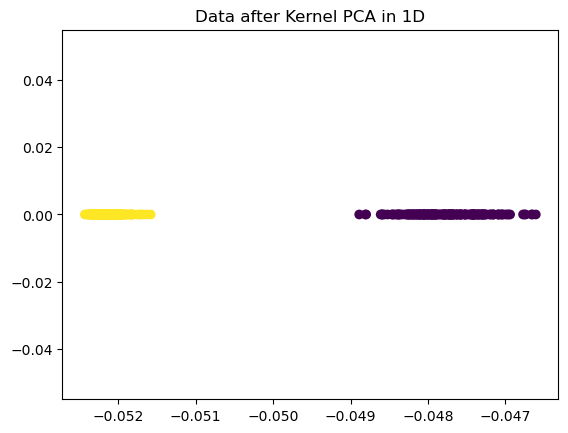

In [ ]:
# 1st compnent 
plt.scatter(X_kpca[:, 0], np.zeros((400,)), c=y)
plt.title('Data after Kernel PCA in 1D')

Text(0.5, 1.0, 'Data after Kernel PCA in 1D')

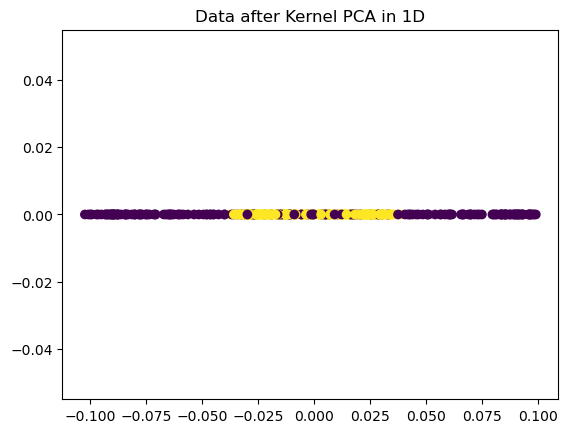

In [ ]:
# 2nd component 
plt.scatter(X_kpca[:, 1], np.zeros((400,)), c=y)
plt.title('Data after Kernel PCA in 1D')

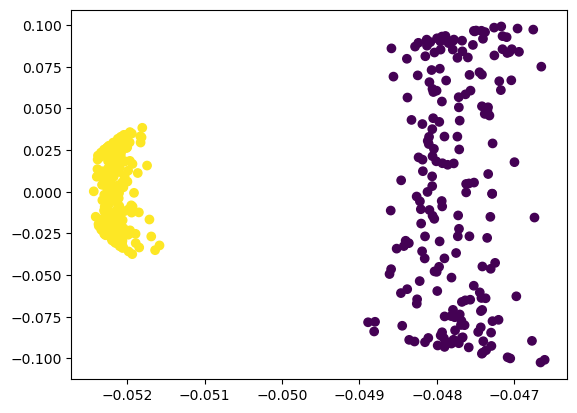

In [ ]:
# 2 dimension ma 
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y)